<div style="background:linear-gradient(135deg,#4c0519 0%,#9f1239 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 182 &middot; Capstone 22 &middot; Factorial Design</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Designing a Factorial Experiment</div>
  <div style="font-size:15px;color:#fecdd3;max-width:820px;line-height:1.6">An eight-run design said line speed was the second-biggest lever on coating strength. Line speed does nothing. Its column in the design matrix is identical to another column, and the estimate belonged to that one all along.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from itertools import product, combinations
from scipy import stats
import statsmodels.api as sm
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
RS, DK, LT, MUT, GD = "#9f1239", "#4c0519", "#fb7185", "#94a3b8", "#047857"
F = list("ABCDE")
LABEL = {"A":"oven temp", "B":"line speed", "C":"viscosity", "D":"cure time", "E":"pressure"}

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-designing-a-factorial-experiment.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
main  = load("MainRuns");      scr  = load("ScreeningRuns")
conf1 = load("Confirmation1"); conf2 = load("Confirmation2")
plan  = load("DesignPlan");    truth = load("truth")
print("main runs:", len(main), "| screening runs:", len(scr))
main.head()

main runs: 33 | screening runs: 16


,run_id,batch,run_order,oven_temp_C,line_speed_m_min,primer_viscosity,cure_time_s,nozzle_pressure_bar,A,B,C,D,E,peel_strength_N
0,F01,1,8,170,8,Low,45,4.0,-1,-1,-1,-1,1,57.09
1,F02,1,6,170,8,Low,75,2.5,-1,-1,-1,1,-1,56.05
2,F03,1,9,170,8,High,45,2.5,-1,-1,1,-1,-1,59.98
3,F04,1,14,170,8,High,75,4.0,-1,-1,1,1,1,58.01
4,F05,1,1,170,12,Low,45,2.5,-1,1,-1,-1,-1,60.83


## Step 1 &middot; The plan, and the arithmetic of runs

Five factors, two levels each. Everything about the design follows from one piece of arithmetic and one budget.

In [2]:
for line in plan.design_plan.fillna(""):
    print(line)

WRITTEN BEFORE ANY PANEL WAS COATED.

G1 RESPONSE: peel strength in newtons, higher is better. One response, measured the same way
   on every panel by the same gauge.
G2 FACTORS: five, each at two levels, chosen by the process engineers as the settings they can
   actually change: oven temperature, line speed, primer viscosity, cure time, nozzle pressure.
G3 THE RUN ARITHMETIC: a full factorial in 5 factors is 2^5 = 32 distinct settings. Replicated
   twice that is 64 runs. Each run needs a line changeover, so 64 is out of budget.
G4 CHOSEN DESIGN: a 16-run half fraction (2^(5-1)), generator E = ABCD, replicated twice = 32
   runs. This is RESOLUTION V: main effects are clear of two-factor interactions, and no two-
   factor interaction is aliased with another.
G5 WHAT WE REJECTED: an 8-run quarter fraction (2^(5-2)) was run last quarter. It is RESOLUTION
   III, which means main effects are aliased with two-factor interactions. See the ScreeningRuns
   sheet and the alias table in th

In [3]:
k = 5
print(f"factors                        {k}")
print(f"full factorial, 2^{k}           {2**k} distinct settings")
print(f"replicated twice               {2*2**k} runs")
print()
for frac, label in [(0, "full 2^5"), (1, "half 2^(5-1)"), (2, "quarter 2^(5-2)")]:
    runs = 2**(k-frac)
    print(f"{label:16s} {runs:3d} settings   {2*runs:3d} runs with 2 replicates   "
          f"{runs-1:2d} degrees of freedom for effects")

factors                        5
full factorial, 2^5           32 distinct settings
replicated twice               64 runs

full 2^5          32 settings    64 runs with 2 replicates   31 degrees of freedom for effects
half 2^(5-1)      16 settings    32 runs with 2 replicates   15 degrees of freedom for effects
quarter 2^(5-2)    8 settings    16 runs with 2 replicates    7 degrees of freedom for effects


**Thirty-two settings is 64 runs, and each run needs a line changeover.** That is the constraint that makes this a design problem rather than an analysis problem. A half fraction gets it to 32 runs; a quarter fraction to 16. The question is what each one costs in what you are able to learn, and the answer has a name.

## Step 2 &middot; The eight-run design that was run first

Last quarter the team ran a quarter fraction, choosing the two extra factors as **D = AB** and **E = AC**. Eight settings, two replicates, sixteen runs. It is cheap and it looks like a complete design: five factors, five effects, all estimated.

In [4]:
base3 = pd.DataFrame(list(product([-1,1], repeat=3)), columns=["A","B","C"])
q = base3.copy(); q["D"] = q.A*q.B; q["E"] = q.A*q.C
print("the eight settings, in coded units")
print(q.to_string(index=False))

the eight settings, in coded units
 A  B  C  D  E
-1 -1 -1  1  1
-1 -1  1  1 -1
-1  1 -1 -1  1
-1  1  1 -1 -1
 1 -1 -1 -1 -1
 1 -1  1 -1  1
 1  1 -1  1 -1
 1  1  1  1  1


## Step 3 &middot; Resolution, and how to see it for yourself

The alias structure is not a theoretical caution. It is visible in the design matrix: build the column for a two-factor interaction and compare it, element by element, with the column for a main effect.

In [5]:
cols = {f: q[f].values for f in F}
for a, b in combinations(F, 2):
    cols[a+":"+b] = q[a].values * q[b].values

print("columns of the 8-run design that are IDENTICAL to a main-effect column:\n")
for f in F:
    same = [n for n, v in cols.items() if n != f and np.array_equal(v, cols[f])]
    print(f"   {f} ({LABEL[f]:10s})  is indistinguishable from  {', '.join(same)}")

columns of the 8-run design that are IDENTICAL to a main-effect column:

   A (oven temp )  is indistinguishable from  B:D, C:E
   B (line speed)  is indistinguishable from  A:D
   C (viscosity )  is indistinguishable from  A:E
   D (cure time )  is indistinguishable from  A:B
   E (pressure  )  is indistinguishable from  A:C


**That is what resolution III means.** With generators D = AB and E = AC the defining relation is I = ABD = ACE = BCDE, and every main effect shares a column with at least one two-factor interaction. The design cannot tell them apart, because within these eight settings **they are the same column of numbers**. No amount of analysis fixes that; the information was never collected.

In [6]:
def effects(d, terms, y="peel_strength_N"):
    yy = d[y].values
    return pd.Series({":".join(t): 2*np.mean(yy*np.prod([d[f].values for f in t], axis=0))
                      for t in terms})

alias = {"A":"A + BD + CE", "B":"B + AD", "C":"C + AE", "D":"D + AB", "E":"E + AC"}
e_s = effects(scr, [(f,) for f in F])
se_s = 2*np.sqrt(scr.groupby(F).peel_strength_N.var().mean()/len(scr))
print(f"{'':3s}{'factor':12s}{'effect (N)':>12s}   what it actually estimates")
for f in F:
    print(f"   {LABEL[f]:12s}{e_s[f]:>+12.2f}   {alias[f]}")
print(f"\n   SE of an effect: about {se_s:.2f} N")

   factor        effect (N)   what it actually estimates
   oven temp         +10.31   A + BD + CE
   line speed         +6.22   B + AD
   viscosity          +1.57   C + AE
   cure time          +1.28   D + AB
   pressure           -0.98   E + AC

   SE of an effect: about 0.86 N


**Line speed comes out at +6.22 newtons, the second-largest effect in the study, on a standard error of 0.86.** By any conventional reading that is a solid, actionable finding. The team read it that way, and the recommendation wrote itself: slow the line down.

## Step 4 &middot; What happened when they acted on it

The line was slowed from 12 to 8 meters per minute and forty panels were measured, twenty before and twenty after.

In [7]:
g = conf1.groupby("setting").peel_strength_N
a = conf1[conf1.setting.str.contains("before")].peel_strength_N
b = conf1[conf1.setting.str.contains("after")].peel_strength_N
t, p = stats.ttest_ind(b, a, equal_var=False)
se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
lo, hi = stats.t.interval(0.95, len(a)+len(b)-2, b.mean()-a.mean(), se)
print(f"before, 12 m/min   {a.mean():.2f} N   (n = {len(a)})")
print(f"after,   8 m/min   {b.mean():.2f} N   (n = {len(b)})")
print(f"\ndifference {b.mean()-a.mean():+.2f} N   95% CI [{lo:+.2f}, {hi:+.2f}]   p = {p:.4f}")
print("\nThe screening design predicted about +6 N. Nothing happened.")

before, 12 m/min   60.74 N   (n = 20)
after,   8 m/min   60.58 N   (n = 20)

difference -0.16 N   95% CI [-0.96, +0.63]   p = 0.6808

The screening design predicted about +6 N. Nothing happened.


**A confirmation run is the cheapest insurance in experimental work, and this is why.** The interval runs from about one newton down to half a newton up. It excludes the +6 the design promised many times over. Something is wrong with the design, not with the process.

## Step 5 &middot; The sixteen-run design

The half fraction uses the generator **E = ABCD**, giving the defining relation I = ABCDE. Main effects are now aliased only with four-factor interactions, and two-factor interactions only with three-factor ones. Under the usual assumption that high-order interactions are negligible, all five main effects and all ten two-factor interactions are separately estimable. That is resolution V.

In [8]:
h = pd.DataFrame(list(product([-1,1], repeat=4)), columns=["A","B","C","D"])
h["E"] = h.A*h.B*h.C*h.D
cols16 = {f: h[f].values for f in F}
for a_, b_ in combinations(F, 2):
    cols16[a_+":"+b_] = h[a_].values * h[b_].values

dupes = 0
for n1, n2 in combinations(cols16, 2):
    if np.array_equal(cols16[n1], cols16[n2]):
        print("  identical:", n1, n2); dupes += 1
print(f"pairs of identical columns among the 5 main effects and 10 two-factor interactions: {dupes}")
print("every one of the 15 effects has its own column, so every one is estimable.")

pairs of identical columns among the 5 main effects and 10 two-factor interactions: 0
every one of the 15 effects has its own column, so every one is estimable.


## Step 6 &middot; Cleaning, and the run that was lost

In [9]:
print(f"rows as delivered           {len(main)}")
d = main.drop_duplicates(subset="run_id")
print(f"after the duplicated row    {len(d)}")
lost = d.peel_strength_N.isna().sum()
d = d.dropna(subset=["peel_strength_N"])
print(f"after the failed gauge      {len(d)}   ({lost} run lost)")
reps = d.groupby(F).size()
print(f"\ndesign points with both replicates: {(reps==2).sum()} of 16")
print("The design is now very slightly unbalanced. Least squares handles that; the hand-computed")
print("contrast formula of Step 3 would not, which is a good reason to fit a model instead.")

rows as delivered           33
after the duplicated row    32
after the failed gauge      31   (1 run lost)

design points with both replicates: 15 of 16
The design is now very slightly unbalanced. Least squares handles that; the hand-computed
contrast formula of Step 3 would not, which is a good reason to fit a model instead.


## Step 7 &middot; The effects, with the batch blocked out

Thirty-two runs need two batches of primer, and batches differ. The plan put replicate 1 entirely on batch 1 and replicate 2 on batch 2, so **batch is the block**. It enters the model as a term, which takes the batch difference out of the error rather than leaving it there to inflate every standard error.

In [10]:
terms = [(f,) for f in F] + [(a_, b_) for i, a_ in enumerate(F) for b_ in F[i+1:]]
X = pd.DataFrame({":".join(t): np.prod([d[f].values for f in t], axis=0) for t in terms})
X["block"] = np.where(d.batch.values == 2, 1, -1)
m = sm.OLS(d.peel_strength_N.values, sm.add_constant(X)).fit()

res = pd.DataFrame({"effect": 2*m.params[1:], "SE": 2*m.bse[1:], "p": m.pvalues[1:]})
res = res.reindex(res.effect.abs().sort_values(ascending=False).index)
print(res.head(8).to_string(float_format=lambda v: f"{v:8.3f}"))
print(f"\nresidual sigma {np.sqrt(m.mse_resid):.3f}")

        effect       SE        p
A        8.467    0.377    0.000
A:D      6.471    0.377    0.000
C:E      2.447    0.377    0.000
C        2.014    0.377    0.000
D        2.007    0.377    0.000
block    1.691    0.377    0.001
E       -1.044    0.377    0.015
B:E     -0.668    0.377    0.098

residual sigma 1.033


**Line speed is +0.17 newtons, p = 0.65.** It was never there. The +6.22 the eight-run design reported belonged to **oven temperature crossed with cure time**, which appears here at +6.47 and could not appear at all in a design where its column and line speed's column were the same numbers.

In [11]:
print(f"line speed, 8-run design   {e_s['B']:+.2f} N")
print(f"line speed, 16-run design  {res.loc['B','effect']:+.2f} N   (SE {res.loc['B','SE']:.2f}, p = {res.loc['B','p']:.2f})")
print(f"A:D interaction, 16-run    {res.loc['A:D','effect']:+.2f} N")
print()
print("the truth that generated the data:")
print(truth[["term","effect_high_minus_low"]].dropna().to_string(index=False))

line speed, 8-run design   +6.22 N
line speed, 16-run design  +0.17 N   (SE 0.38, p = 0.65)
A:D interaction, 16-run    +6.47 N

the truth that generated the data:
                       term  effect_high_minus_low
         A oven temperature                    8.0
               B line speed                    0.0
         C primer viscosity                    2.4
                D cure time                    1.6
          E nozzle pressure                   -0.8
A:D temperature x cure time                    6.4
   C:E viscosity x pressure                    2.2
             batch 2 offset                    2.0


## Step 8 &middot; What blocking bought

The block is worth stating as a number, because the temptation is always to skip it.

In [12]:
m_nb = sm.OLS(d.peel_strength_N.values, sm.add_constant(X.drop(columns="block"))).fit()
print(f"                      blocked     unblocked")
print(f"residual sigma       {np.sqrt(m.mse_resid):8.3f}   {np.sqrt(m_nb.mse_resid):9.3f}")
print(f"SE of an effect      {2*m.bse['A']:8.3f}   {2*m_nb.bse['A']:9.3f}   "
      f"({2*m_nb.bse['A']/(2*m.bse['A'])-1:+.0%})")
print(f"\nestimated batch-2 offset {res.loc['block','effect']:+.2f} N   (the true offset was +2.00)")
print("\nNote what blocking did NOT do: the batch effect is still there in the process.")
print("Blocking removes it from the ERROR, so the factor effects are measured against a")
print("smaller yardstick. Randomizing batches across runs would have converted the same")
print("variation into noise instead, which is worse when you can predict it.")

                      blocked     unblocked
residual sigma          1.033       1.557
SE of an effect         0.377       0.567   (+50%)

estimated batch-2 offset +1.69 N   (the true offset was +2.00)

Note what blocking did NOT do: the batch effect is still there in the process.
Blocking removes it from the ERROR, so the factor effects are measured against a
smaller yardstick. Randomizing batches across runs would have converted the same
variation into noise instead, which is worse when you can predict it.


## Step 9 &middot; Randomization, against the drift nobody mentioned

The oven creeps upward across a shift. Nobody measured that, and nobody had to, because run order was randomized. The value of randomizing is easiest to see by simulating the alternative: running the settings in a convenient order instead.

In [13]:
rng = np.random.default_rng(20)
COEF = {"A":4.0,"B":0.0,"C":1.2,"D":0.8,"E":-0.4}
INTER = {("A","D"):3.2, ("C","E"):1.1}
DRIFT, SIGMA = 0.05, 1.4

def simulate(sort_by=None, R=2000):
    out = np.empty(R)
    for r in range(R):
        dd = pd.concat([h, h], ignore_index=True)
        for rep in (0, 1):
            sl = slice(rep*16, (rep+1)*16)
            blk = dd.iloc[sl]
            pos = (np.argsort(np.argsort(blk[sort_by].values, kind="stable"))
                   if sort_by else rng.permutation(16))
            dd.loc[dd.index[sl], "pos"] = pos
        y = np.full(len(dd), 62.0)
        for f, c in COEF.items(): y += c*dd[f].values
        for (f1, f2), c in INTER.items(): y += c*dd[f1].values*dd[f2].values
        y += DRIFT*dd["pos"].values + rng.normal(0, SIGMA, len(dd))
        out[r] = 2*np.mean(y*dd["E"].values)
    return out

rand_E = simulate(None)
sort_E = simulate("E")
print(f"true effect of nozzle pressure (E): {2*COEF['E']:+.2f} N\n")
print(f"randomized run order   mean estimate {rand_E.mean():+.3f}   bias {rand_E.mean()-2*COEF['E']:+.3f}")
print(f"runs sorted by E       mean estimate {sort_E.mean():+.3f}   bias {sort_E.mean()-2*COEF['E']:+.3f}")
print(f"\nSorting the runs by one factor moves that factor's estimate by "
      f"{sort_E.mean()-rand_E.mean():+.2f} N.")

true effect of nozzle pressure (E): -0.80 N

randomized run order   mean estimate -0.805   bias -0.005
runs sorted by E       mean estimate -0.408   bias +0.392

Sorting the runs by one factor moves that factor's estimate by +0.40 N.


**The drift bias is about +0.4 newtons, and it lands wherever you sorted.** Against the temperature effect of 8.5 that is a five percent distortion nobody would notice. Against nozzle pressure it is half the effect, and it reverses the apparent conclusion about whether pressure matters. You cannot know in advance which of your effects are small, which is the whole argument for randomizing: it converts a bias you cannot see into noise you can measure.

## Step 10 &middot; The interaction, and the confirmation run

The recommendation is not a factor. It is a combination.

In [14]:
cell = d.groupby(["A","D"]).peel_strength_N.mean().unstack()
cell.index = ["temp 170 C", "temp 190 C"]; cell.columns = ["cure 45 s", "cure 75 s"]
print(cell.round(2).to_string())
print(f"\nraising temperature at short cure:  {cell.iloc[1,0]-cell.iloc[0,0]:+.2f} N")
print(f"raising temperature at long cure:   {cell.iloc[1,1]-cell.iloc[0,1]:+.2f} N")
print(f"raising both together:              {cell.iloc[1,1]-cell.iloc[0,0]:+.2f} N")

            cure 45 s  cure 75 s
temp 170 C      60.89      56.73
temp 190 C      63.19      71.67

raising temperature at short cure:  +2.30 N
raising temperature at long cure:   +14.94 N
raising both together:              +10.78 N


In [15]:
a2 = conf2[conf2.setting.str.contains("baseline")].peel_strength_N
b2 = conf2[conf2.setting.str.contains("recommended")].peel_strength_N
t2, p2 = stats.ttest_ind(b2, a2, equal_var=False)
se2 = np.sqrt(a2.var(ddof=1)/len(a2) + b2.var(ddof=1)/len(b2))
lo2, hi2 = stats.t.interval(0.95, len(a2)+len(b2)-2, b2.mean()-a2.mean(), se2)
print(f"baseline    170 C, 45 s   {a2.mean():.2f} N")
print(f"recommended 190 C, 75 s   {b2.mean():.2f} N")
print(f"\ndifference {b2.mean()-a2.mean():+.2f} N   95% CI [{lo2:+.2f}, {hi2:+.2f}]   p = {p2:.4g}")

baseline    170 C, 45 s   60.54 N
recommended 190 C, 75 s   70.00 N

difference +9.46 N   95% CI [+8.61, +10.31]   p = 3.975e-21


**Nine and a half newtons, confirmed on fresh panels.** The design that cost twice as much found the lever the cheap design pointed away from, and the confirmation run is what turns an estimate into a decision somebody can sign.

## Step 11 &middot; The two pictures worth keeping

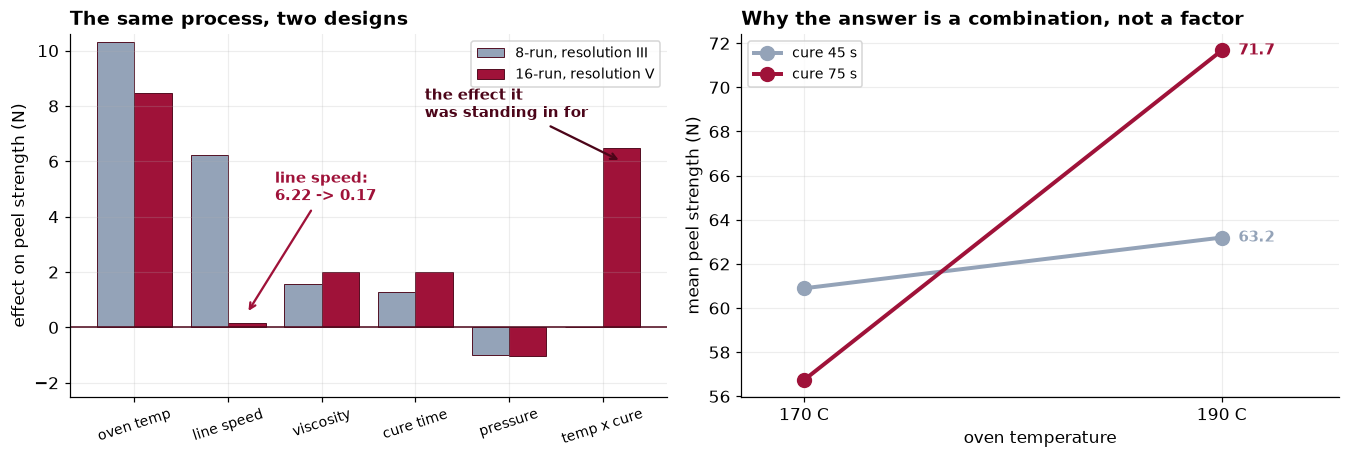

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3))

ax = axes[0]
names = ["A","B","C","D","E"]
scr_v = [e_s[f] for f in names]
main_v = [res.loc[f,"effect"] for f in names] + [res.loc["A:D","effect"]]
xs = np.arange(6)
ax.bar(xs-0.2, scr_v+[0], 0.4, color=MUT, edgecolor=DK, lw=0.6, label="8-run, resolution III")
ax.bar(xs+0.2, main_v, 0.4, color=RS, edgecolor=DK, lw=0.6, label="16-run, resolution V")
ax.set_xticks(xs); ax.set_xticklabels([LABEL[f] for f in names]+["temp x cure"], fontsize=9, rotation=18)
ax.axhline(0, color=DK, lw=1)
ax.annotate("line speed:\n6.22 -> 0.17", xy=(1.2, 0.5), xytext=(1.5, 4.6), fontsize=9.5,
            fontweight="bold", color=RS, arrowprops=dict(arrowstyle="->", color=RS, lw=1.5))
ax.annotate("the effect it\nwas standing in for", xy=(5.2, 6.0), xytext=(3.1, 7.6), fontsize=9.5,
            fontweight="bold", color=DK, arrowprops=dict(arrowstyle="->", color=DK, lw=1.5))
ax.set_ylabel("effect on peel strength (N)")
ax.set_title("The same process, two designs")
ax.legend(fontsize=9, loc="upper right"); ax.set_ylim(-2.5, 10.6)

ax = axes[1]
for j, (lab, col) in enumerate(zip(["cure 45 s","cure 75 s"], [MUT, RS])):
    ax.plot([0,1], cell.iloc[:,j].values, "-o", color=col, lw=2.6, ms=9, label=lab)
    ax.annotate(f"{cell.iloc[1,j]:.1f}", xy=(1, cell.iloc[1,j]), xytext=(1.04, cell.iloc[1,j]),
                fontsize=10, fontweight="bold", color=col, va="center")
ax.set_xticks([0,1]); ax.set_xticklabels(["170 C","190 C"]); ax.set_xlim(-0.15, 1.28)
ax.set_xlabel("oven temperature"); ax.set_ylabel("mean peel strength (N)")
ax.set_title("Why the answer is a combination, not a factor")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

**Left:** the same five factors measured two ways. Line speed collapses from the second-largest effect to nothing, and the temperature-by-cure-time interaction, which the eight-run design had no column for, takes its place. **Right:** the interaction itself. Raising the temperature buys little at short cure and a great deal at long cure, so neither factor alone is the recommendation.

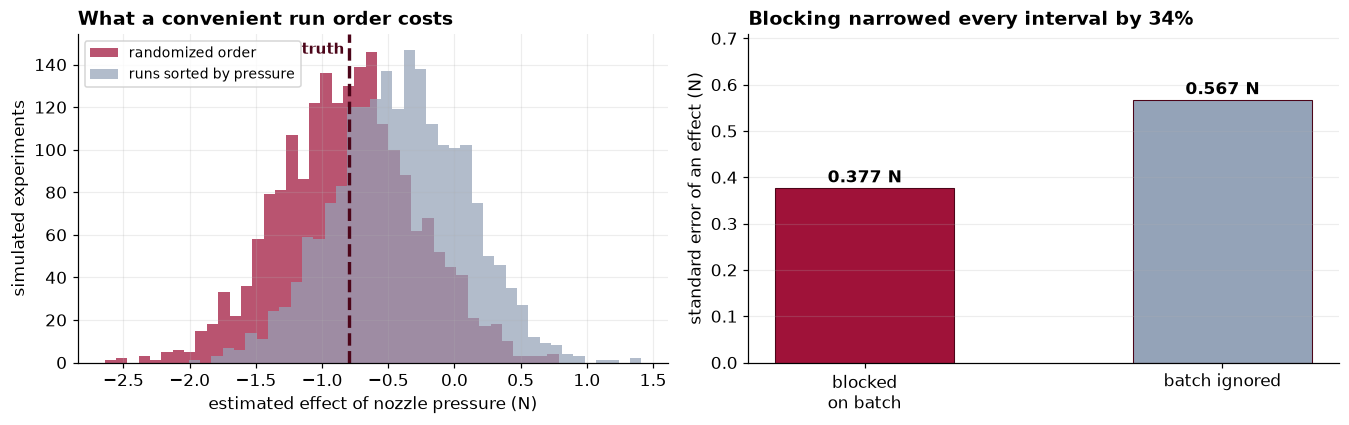

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.0))

ax = axes[0]
ax.hist(rand_E, bins=40, color=RS, alpha=0.72, edgecolor="none", label="randomized order")
ax.hist(sort_E, bins=40, color=MUT, alpha=0.72, edgecolor="none", label="runs sorted by pressure")
ax.axvline(2*COEF["E"], color=DK, lw=2.2, ls="--")
ax.text(2*COEF["E"]-0.03, ax.get_ylim()[1]*0.94, "truth", ha="right", fontsize=9.5,
        fontweight="bold", color=DK)
ax.set_xlabel("estimated effect of nozzle pressure (N)"); ax.set_ylabel("simulated experiments")
ax.set_title("What a convenient run order costs"); ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
lbl = ["blocked\non batch", "batch ignored"]
vals = [2*m.bse["A"], 2*m_nb.bse["A"]]
bb = ax.bar(lbl, vals, color=[RS, MUT], edgecolor=DK, lw=0.7, width=0.5)
for rect, v in zip(bb, vals):
    ax.text(rect.get_x()+rect.get_width()/2, v+0.012, f"{v:.3f} N", ha="center", fontweight="bold")
ax.set_ylabel("standard error of an effect (N)")
ax.set_ylim(0, max(vals)*1.25); ax.grid(axis="x", alpha=0)
ax.set_title(f"Blocking narrowed every interval by {1-2*m.bse['A']/(2*m_nb.bse['A']):.0%}")
plt.tight_layout(); plt.show()

**Left:** two thousand simulated experiments each way. Randomizing centers the estimate on the truth; running the settings in a convenient order shifts the whole distribution by about four tenths of a newton, which happens to be half of this particular effect. **Right:** what the block was worth. Same runs, same data, a third off every standard error.

## Step 12 &middot; Ethics, bias, and limits
- **A cheap design is not a cheap decision.** The eight-run study cost a fifth of the sixteen-run one and produced a recommendation that wasted a line change and a quarter of production time. Report the resolution of a fractional design next to its results, every time, because a reader cannot infer it from the effect table.
- **Aliasing is a property of the design, not of the data.** No analysis recovers what the design did not separate. The only honest options are to run the additional runs that break the alias, or to state the alias chain alongside the estimate and let the reader see the ambiguity.
- **Say which interactions you assumed away.** Resolution V is safe under the assumption that three-factor and higher interactions are negligible. That is usually reasonable in a physical process and it is an assumption, not a fact, and it should appear in the write-up rather than in the analyst's head.
- **Randomize even when it is inconvenient.** Sorting runs by temperature saves real time on a production line, and it buys that time by confounding the factor you sorted on with everything that drifts. The cost is invisible in the output.
- **Block what you can predict, randomize what you cannot.** Batch was known in advance and became a block. Oven drift was not measured at all and was handled by randomization. Using the wrong tool for either would have left variance in the error or bias in an effect.
- **Confirm before you commit.** Both recommendations in this chapter were tested on fresh panels before anything changed on the line. The first confirmation is the reason anybody discovered the screening design had misled them, and it cost forty panels.
- **A designed experiment on a production line is not free of consequence.** Running deliberately poor settings produces genuinely worse product, and somebody has to decide what happens to it. That is a disposal and disclosure question, not a statistical one, and it belongs in the plan.

---
**From analysis to report.** The notebook carries the chain: the run arithmetic that forces a fraction, the alias structure shown as identical columns rather than asserted, the screening result and the confirmation run that contradicted it, the sixteen-run design that separates line speed from the temperature-by-cure interaction, what blocking and randomization were each worth in newtons, and a final confirmation on fresh panels. The written reports turn it into a recommendation a plant manager can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.